<a href="https://www.kaggle.com/code/kadapagle/peningkatan-kualitas-citra-medis?scriptVersionId=351435003" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Mengambil Sampel Data

# Pendahuluan 
## A. Identitas
| Nama | NPM | 
| -------- | -------- | 
| M Daffa Arrafi| 24081010035 | 
| Eagan Rainmahasin Alma'qushai| 24081010139 | 
| Daffa Najwan Fadhilah| 24081010172 | 

## B. Laporan
Laporan dan penjelasan terperinci untuk notebook ini dapat diakses melalui tautan berikut: <br>
<img src="https://img.icons8.com/fluency/48/google-docs--v1.png" width="20" height="20" style="vertical-align: middle;"> 
[Document](https://docs.google.com/document/d/1gE4YMEY3KzuJVmRmdh1Xr6TahGEmMtwKv0POYSLculg/edit?usp=sharing) <br>
<img src="https://img.icons8.com/color/48/microsoft-powerpoint-2019--v1.png" width="20" height="20" style="vertical-align: middle;"> [Power Point](https://canva.link/hje2kshzh4xl6rm) 

## C. Datasets
Dataset diambil dari Kaggle dan bersumber dari beberapa citra medis dari beberapa modalitas. Berikut rincian dataset:<br>
**1. Osteoarthritis**  
Osteoarthritis adalah penyakit sendi akibat rusaknya tulang rawan pelindung ujung tulang. Dataset berasal dari citra X-ray.  
[Dataset Osteoarthritis (dhruvacube)](https://www.kaggle.com/datasets/dhruvacube/osteoarthritis)

**2. Chest**  
Dataset ini berisi beragam chest X-ray dengan beragam diagnosa dari 30,805 pasien unik.  
[Dataset NIH Chest X-rays Sample (nih-chest-xrays)](https://www.kaggle.com/datasets/nih-chest-xrays/sample)

**3. Batu ginjal**  
Dataset ini didapat dari hasil USG dan didapat dari beberapa rumah sakit yang berasal dari Samsung ultrasound machines.  
[Dataset Kidney Stone (imtkaggleteam)](https://www.kaggle.com/datasets/imtkaggleteam/kidney-stone-classification-and-object-detection)

**4. Tumor otak**  
Tumor otak merupakan penyakit akibat pertumbuhan sel otak yang tidak terkendali. Dataset ini merupakan kumpulan dari tiga dataset lain dan diambil menggunakan MRI lalu dikategorikan dalam empat kelas.  
[Dataset Brain Tumor MRI (masoudnickparvar)](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

**5. Adenocarcinoma**  
Dataset ini berisi foto CT-scan dari adenocarcinoma atau kanker pada paru-paru.  
[Dataset Chest CT-Scan Images (mohamedhanyyy)](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

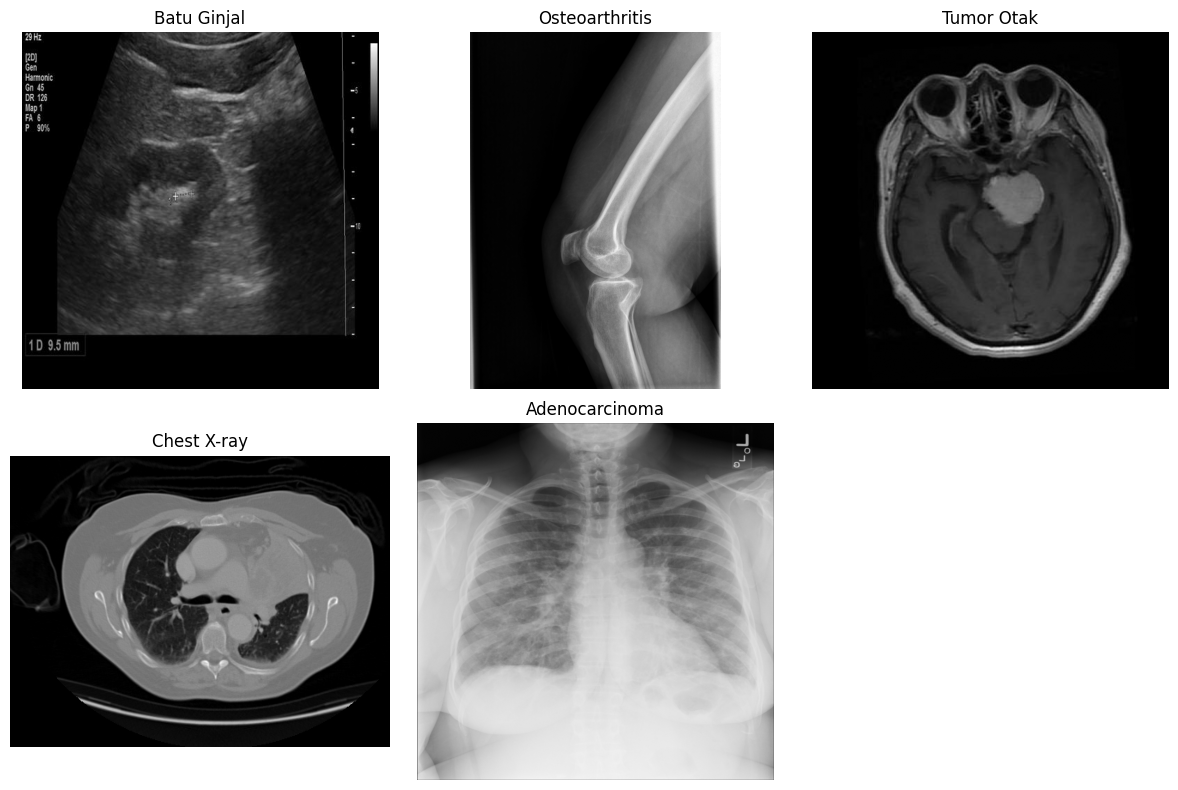

In [2]:
batu_ginjal = cv2.imread('/kaggle/input/datasets/imtkaggleteam/kidney-stone-classification-and-object-detection/stone/Stone_1.JPG', cv2.IMREAD_GRAYSCALE)
osteoarthritis = cv2.imread('/kaggle/input/datasets/dhruvacube/osteoarthritis/withoutKLGrade/withoutKLGrade/patient/014d8da596bf50d1.jpg', cv2.IMREAD_GRAYSCALE)
tumor_otak = cv2.imread('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/meningioma/Tr-aug-me_1.jpg', cv2.IMREAD_GRAYSCALE)
chest = cv2.imread('/kaggle/input/datasets/nih-chest-xrays/sample/sample/sample/images/00000154_001.png', cv2.IMREAD_GRAYSCALE)
adenocarcinoma = cv2.imread('/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/test/adenocarcinoma/000119 (4).png', cv2.IMREAD_GRAYSCALE)

gambar = [
    batu_ginjal,
    osteoarthritis,
    tumor_otak,
    adenocarcinoma,
    chest
]

judul = [
    'Batu Ginjal',
    'Osteoarthritis',
    'Tumor Otak',
    'Chest X-ray',
    'Adenocarcinoma'
]

plt.figure(figsize=(12, 8))

for i in range(len(gambar)):
    plt.subplot(2, 3, i + 1)

    plt.imshow(gambar[i], cmap='gray')

    plt.title(judul[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Histogram Equlization

# (CLAHE) Contras Limited Adaptive Histogram Equalization 

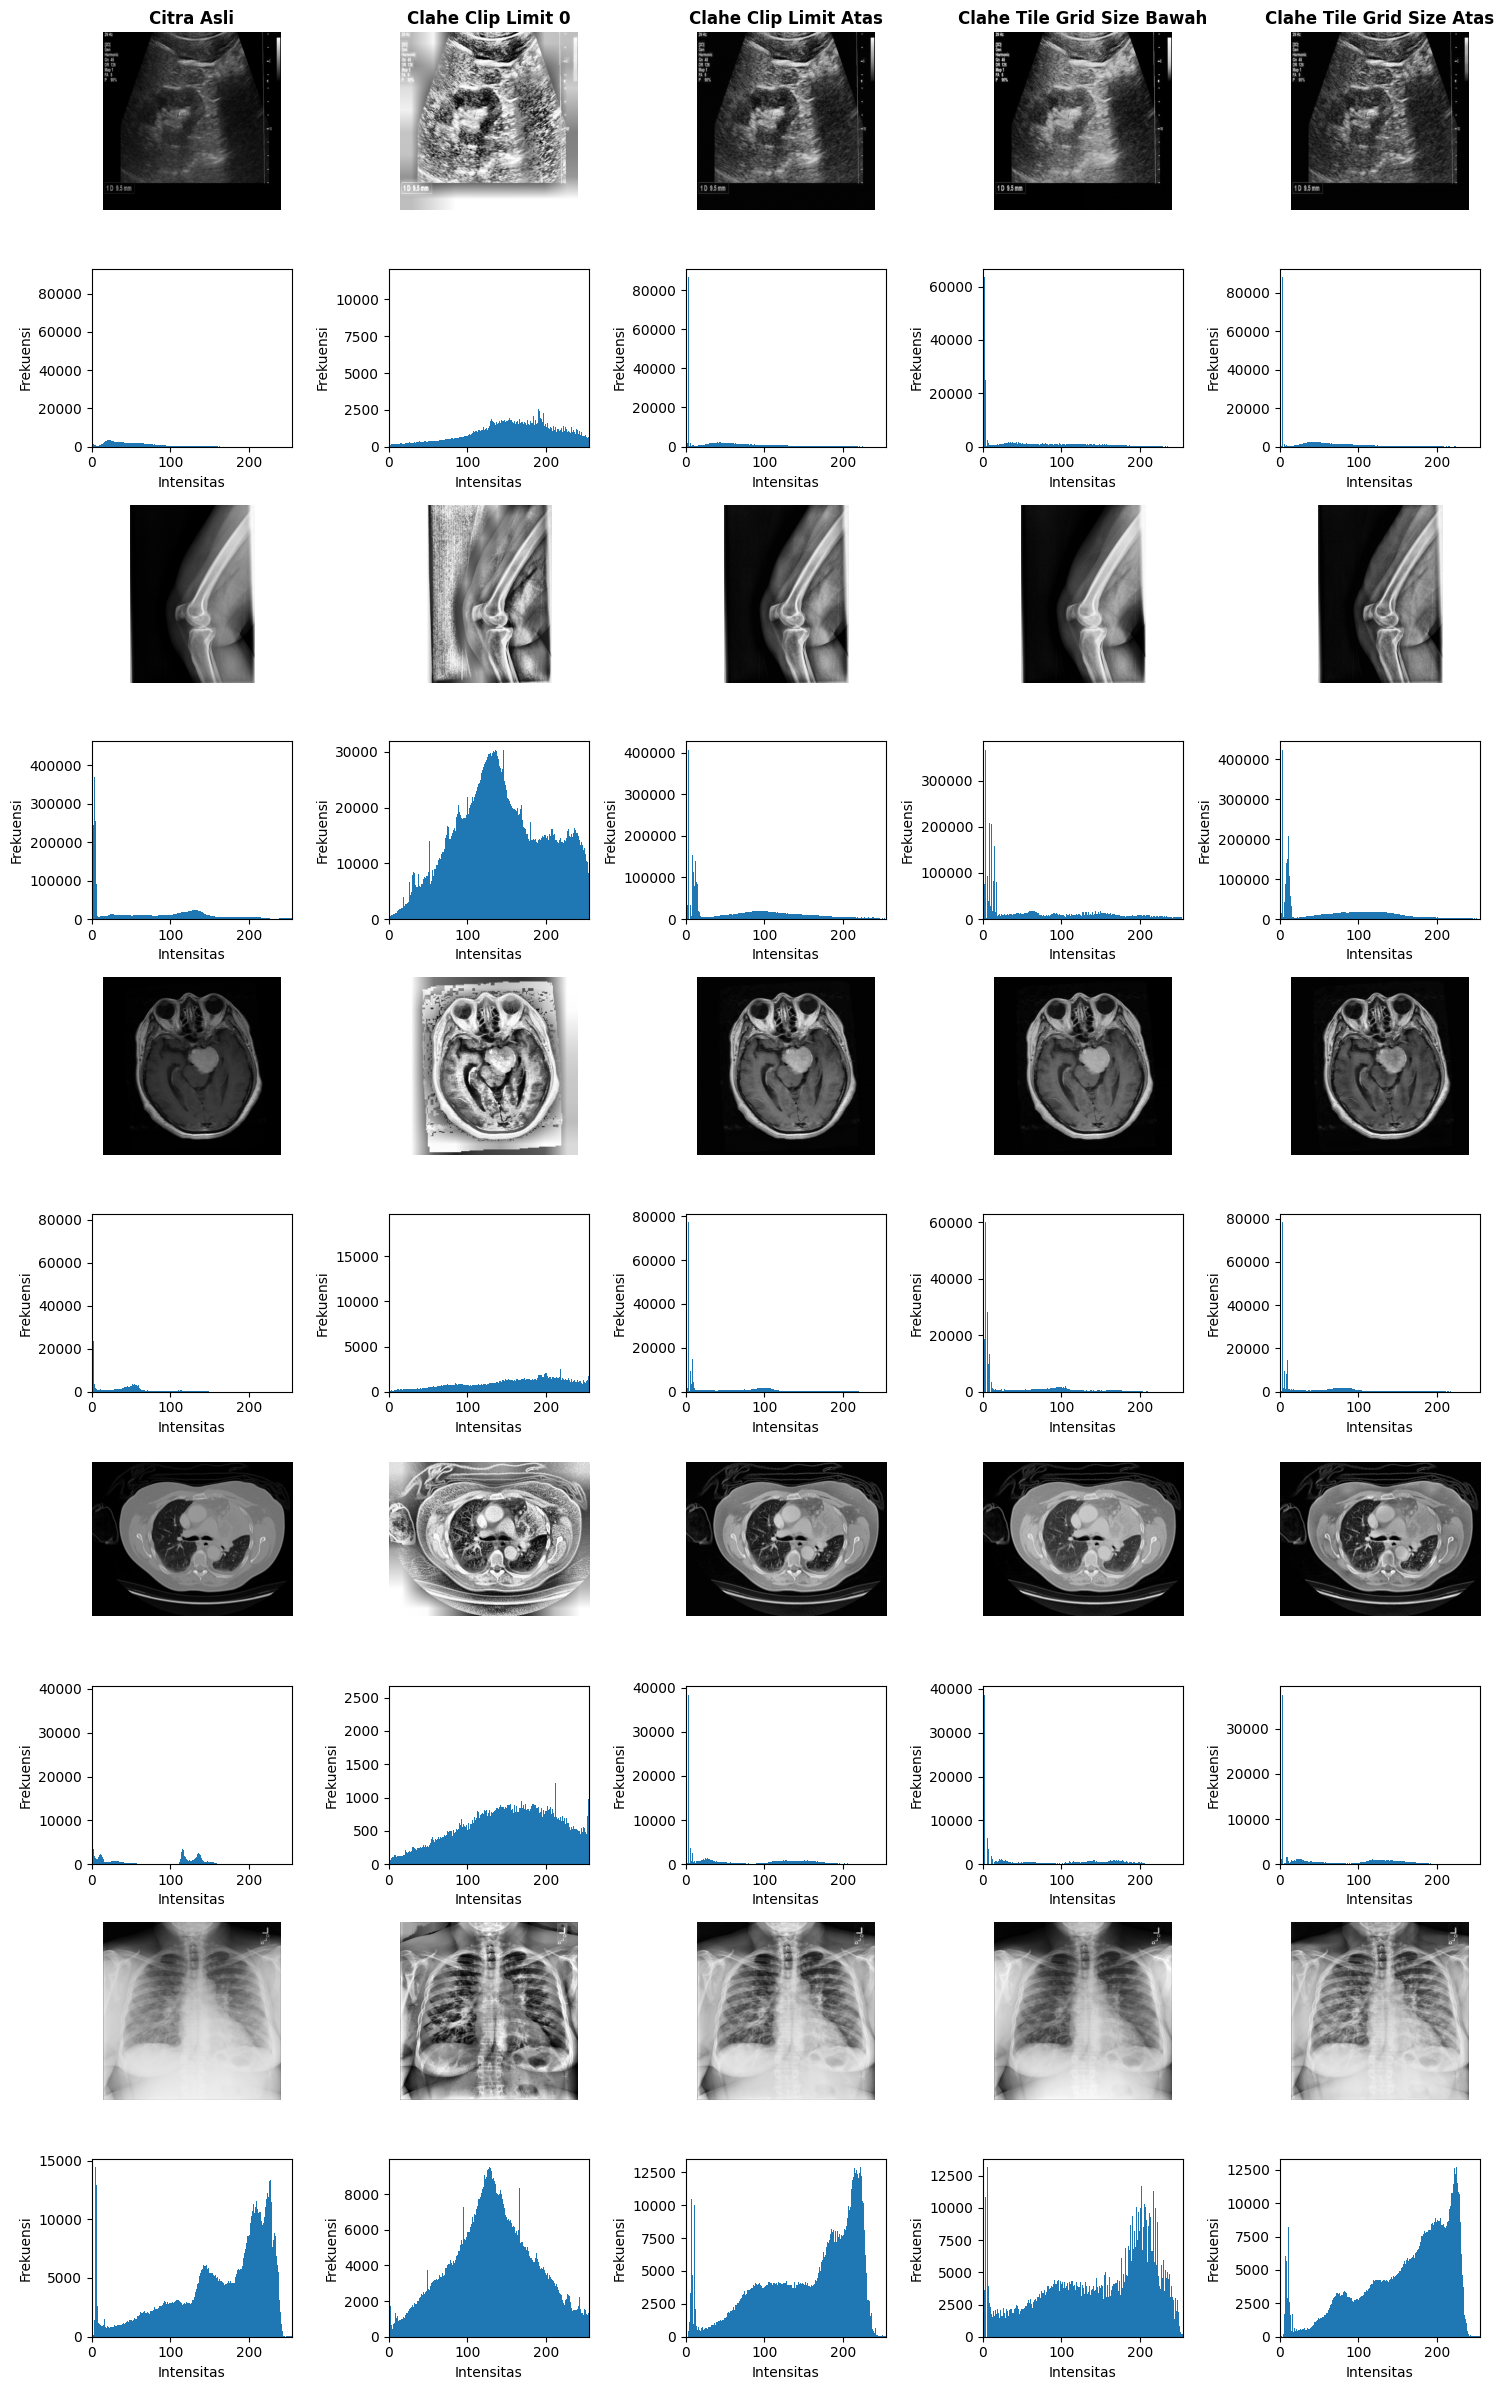

In [3]:
claheCLAI = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
claheCL0I = cv2.createCLAHE(clipLimit=0, tileGridSize=(8, 8))
claheTGSBI = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(2, 2))
claheTGSAI = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(20, 20))
    
claheCLA = []
claheCL0 = []
claheTGSB = []
claheTGSA = []
    
for img in gambar:
    claheCLA.append(claheCLAI.apply(img))
    claheCL0.append(claheCL0I.apply(img))
    claheTGSB.append(claheTGSBI.apply(img))
    claheTGSA.append(claheTGSAI.apply(img))
    
fig, axes = plt.subplots(10, 5, figsize=(15, 24))
    
nama_proses = [
    'Citra Asli',
    'Clahe Clip Limit 0',
    'Clahe Clip Limit Atas',
    'Clahe Tile Grid Size Bawah',
    'Clahe Tile Grid Size Atas'
        
]
    
for row in range(len(gambar)):
    hasil = [
        gambar[row],
        claheCL0[row],
        claheCLA[row],
        claheTGSB[row],
        claheTGSA[row]
    ]
    for col in range(5):
        baris_gambar = row * 2
        axes[baris_gambar, col].imshow(hasil[col], cmap='gray')
        axes[baris_gambar, col].axis('off')
        if row == 0:
            axes[baris_gambar, col].set_title(nama_proses[col],fontsize=12,fontweight='bold')

        baris_histogram = row * 2 + 1
        axes[baris_histogram, col].hist(hasil[col].ravel(),bins=256,range=(0, 256))
        axes[baris_histogram, col].set_xlim(0, 255)
        axes[baris_histogram, col].set_xlabel('Intensitas')
        axes[baris_histogram, col].set_ylabel('Frekuensi')

        axes[baris_gambar, 0].set_ylabel(judul[row],fontsize=12,fontweight='bold')


plt.tight_layout()
plt.show()

# Gamma Correction

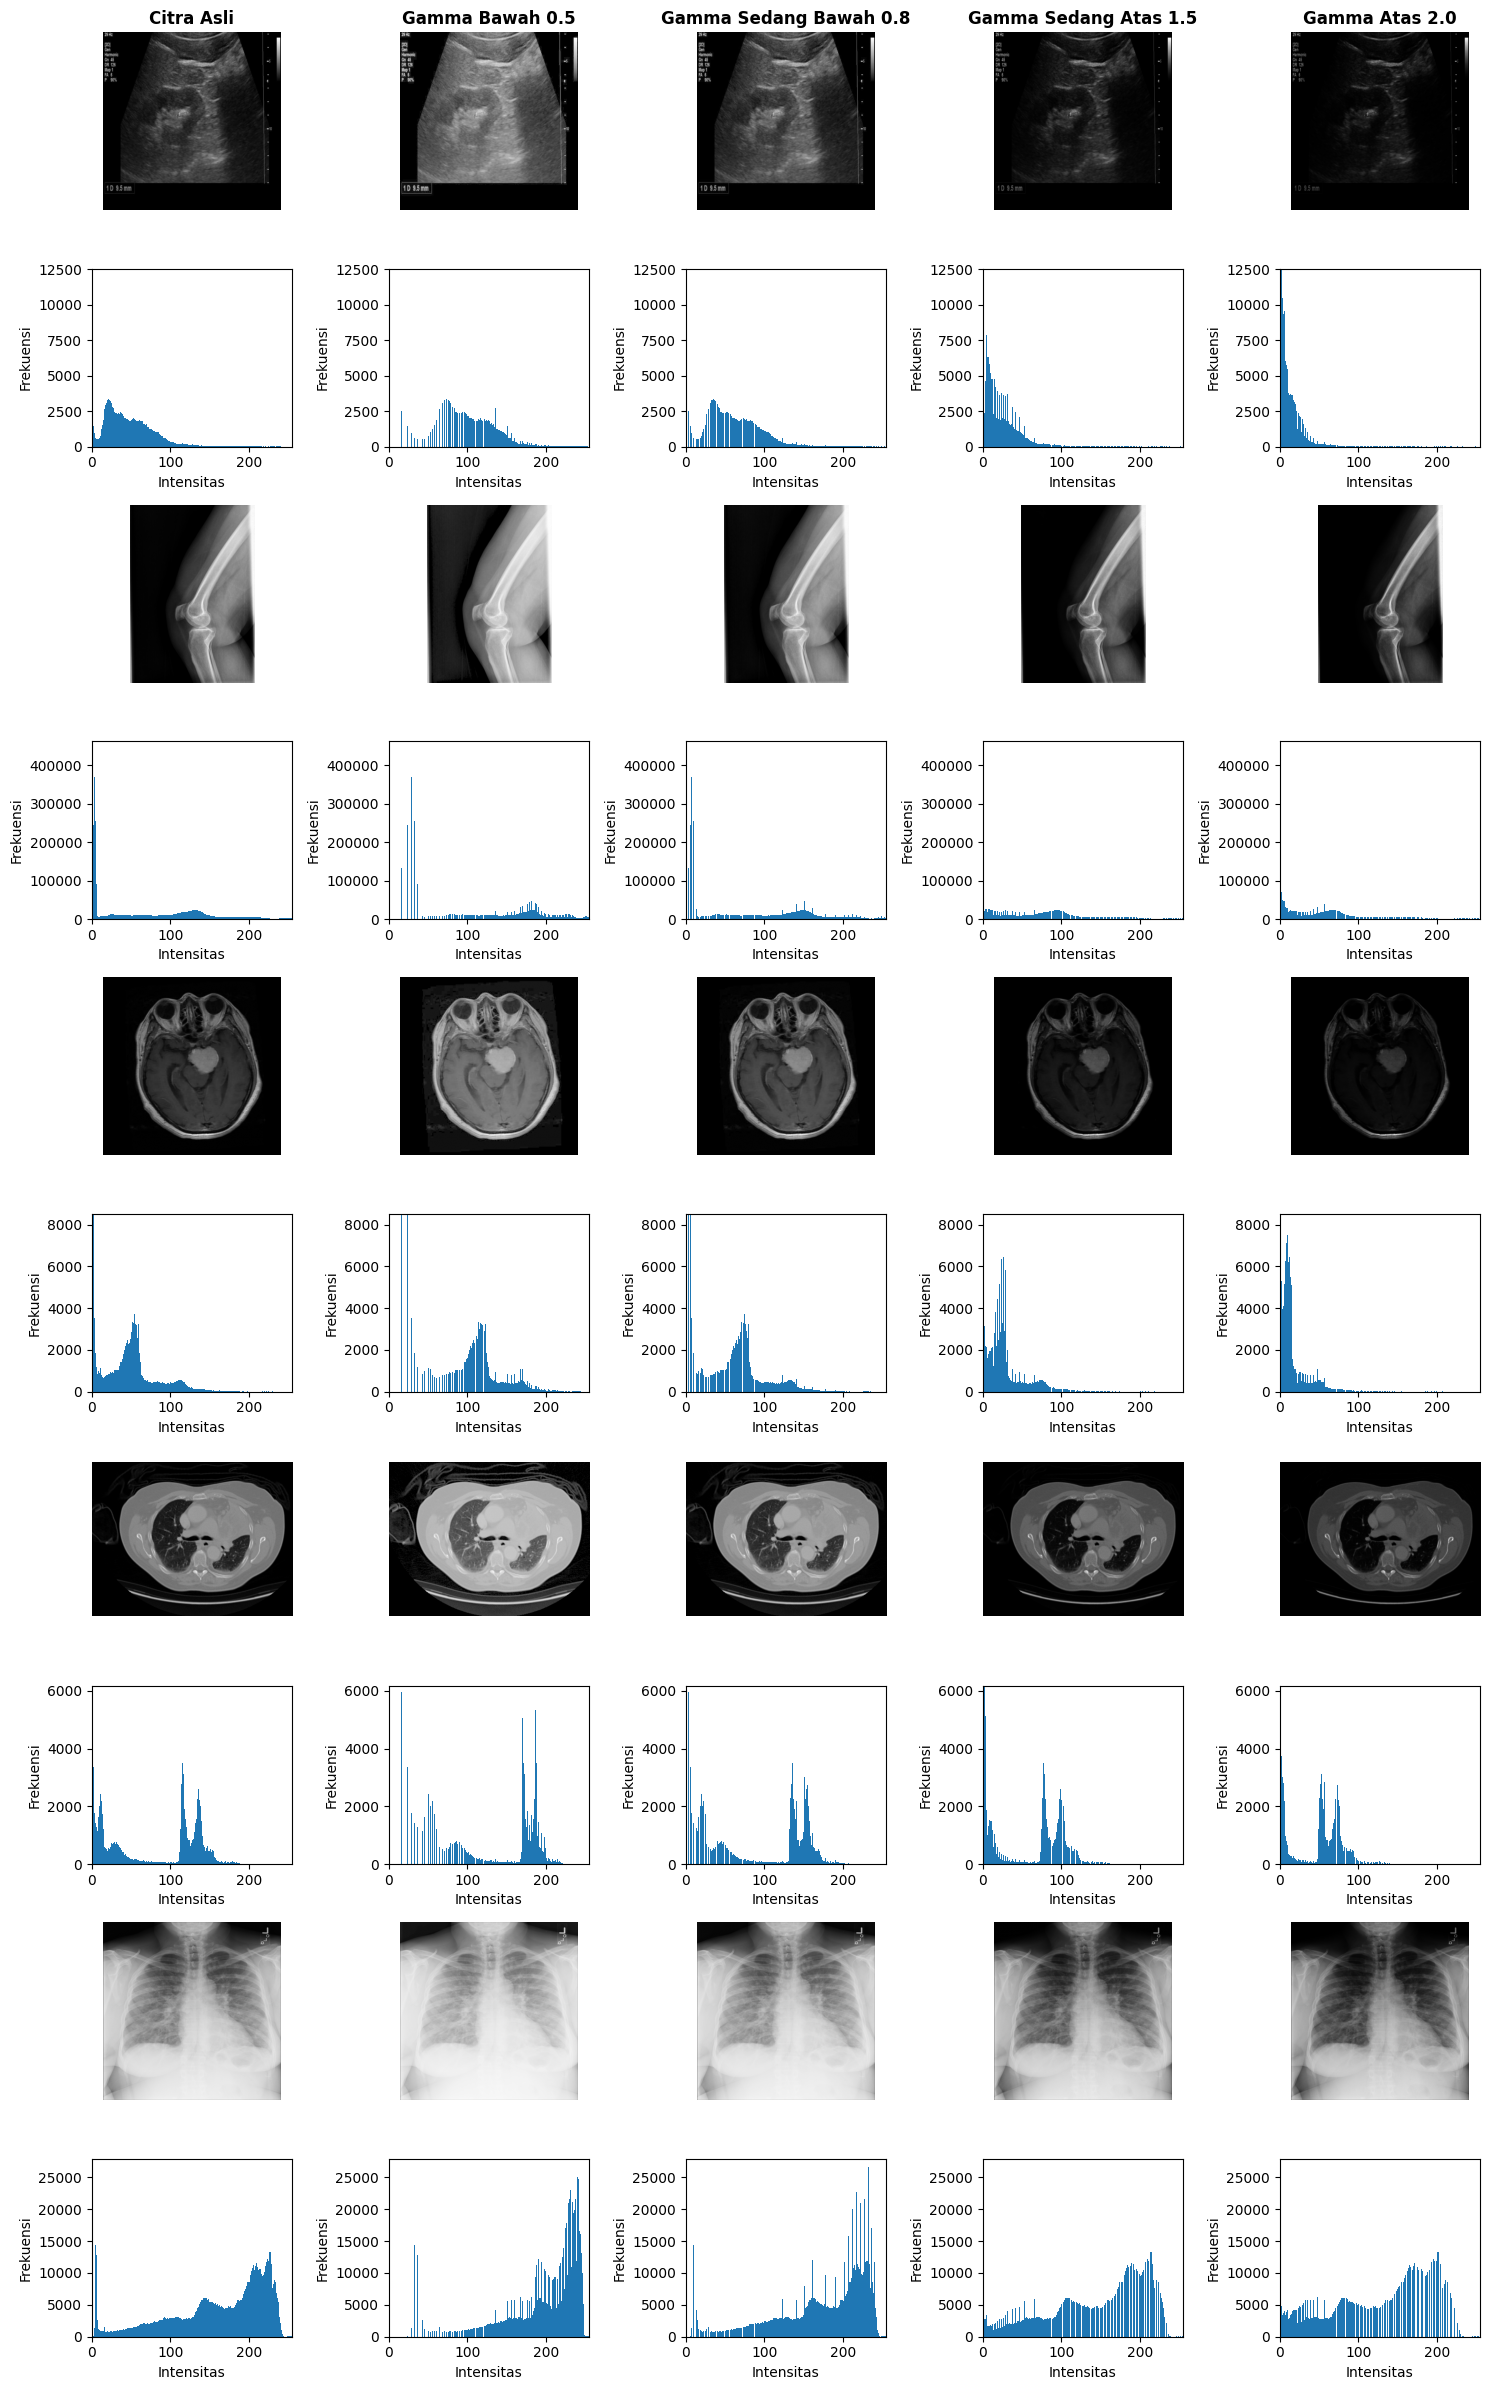

In [4]:
    def gamma_correction(citra, gamma=1.0):                                                                                                                                                                                
        # lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8") 
        # lut = np.array([np.round(((i / 255.0) ** gamma) * 255) for i in range(256)]).astype("uint8")
        lut = np.clip(np.round(((np.arange(256) / 255.0) ** gamma) * 255), 0, 255).astype(np.uint8)
        return cv2.LUT(citra, lut)                                                                                                                                                                                         
                                                                                                                                                                                                                           
    def get_dynamic_ylim(data):                                                                                                                                                                                            
        counts, _ = np.histogram(data.ravel(), bins=256, range=(0, 256))                                                                                                                                                   
        sorted_counts = np.sort(counts)                                                                                                                                                                                    
        fourth = sorted_counts[-4]                                                                                                                                                                                         
        max_c = sorted_counts[-1]                                                                                                                                                                                          
                                                                                                                               
        if fourth > 0 and max_c > 2.0 * fourth:                                                                                                                                                                            
            return fourth * 1.2                                                                                                                                                                                            
        return max_c * 1.05                                                                                                                                                                                                
                                                                                                                                                                                                                           
    gamma_bawah = 0.5                                                                                                                                                                                                      
    gamma_sedang_bawah = 0.8                                                                                                                                                                                               
    gamma_sedang_atas = 1.5                                                                                                                                                                                                
    gamma_atas = 2.0                                                                                                                                                                                                       
                                                                                                                                                                                                                           
    gamma_GB = []                                                                                                                                                                                                          
    gamma_GSB = []                                                                                                                                                                                                         
    gamma_GSA = []                                                                                                                                                                                                         
    gamma_GA = []                                                                                                                                                                                                          
                                                                                                                                                                                                                           
    for img in gambar:                                                                                                                                                                                                     
        gamma_GB.append(gamma_correction(img, gamma_bawah))                                                                                                                                                                
        gamma_GSB.append(gamma_correction(img, gamma_sedang_bawah))                                                                                                                                                        
        gamma_GSA.append(gamma_correction(img, gamma_sedang_atas))                                                                                                                                                         
        gamma_GA.append(gamma_correction(img, gamma_atas))                                                                                                                                                                 
                                                                                                                                                                                                                           
    fig, axes = plt.subplots(10, 5, figsize=(15, 24))                                                                                                                                                                      
                                                                                                                                                                                                                           
    nama_proses = [                                                                                                                                                                                                        
        'Citra Asli',                                                                                                                                                                                                      
        f'Gamma Bawah {gamma_bawah}',                                                                                                                                                                            
        f'Gamma Sedang Bawah {gamma_sedang_bawah}',                                                                                                                                                              
        f'Gamma Sedang Atas {gamma_sedang_atas}',                                                                                                                                                                
        f'Gamma Atas {gamma_atas}'                                                                                                                                                                               
    ]                                                                                                                                                                                                                      
                                                                                                                                                                                                                           
    for row in range(len(gambar)):                                                                                                                                                                                         
        hasil = [                                                                                                                                                                                                          
            gambar[row],                                                                                                                                                                                                   
            gamma_GB[row],                                                                                                                                                                                                 
            gamma_GSB[row],                                                                                                                                                                                                
            gamma_GSA[row],                                                                                                                                                                                                
            gamma_GA[row]                                                                                                                                                                                                  
        ]                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                                                                                         
        row_ylim = max(get_dynamic_ylim(img) for img in hasil)                                                                                                                                                             
                                                                                                                                                                                                                           
        for col in range(5):                                                                                                                                                                                               
            baris_gambar = row * 2                                                                                                                                                                                         
            axes[baris_gambar, col].imshow(hasil[col], cmap='gray')                                                                                                                                                        
            axes[baris_gambar, col].axis('off')                                                                                                                                                                            
            if row == 0:                                                                                                                                                                                                   
                axes[baris_gambar, col].set_title(nama_proses[col], fontsize=12, fontweight='bold')                                                                                                                        
                                                                                                                                                                                                                           
            baris_histogram = row * 2 + 1                                                                                                                                                                                  
            axes[baris_histogram, col].hist(hasil[col].ravel(), bins=256, range=(0, 256))                                                                                                                                  
            axes[baris_histogram, col].set_xlim(0, 255)                                                                                                                                                                    
            axes[baris_histogram, col].set_ylim(0, row_ylim)                                                                                                              
            axes[baris_histogram, col].set_xlabel('Intensitas')                                                                                                                                                            
            axes[baris_histogram, col].set_ylabel('Frekuensi')                                                                                                                                                             
                                                                                                                                                                                                                           
            axes[baris_gambar, 0].set_ylabel(judul[row], fontsize=12, fontweight='bold')                                                                                                                                   
                                                                                                                                                                                                                    
    plt.tight_layout()                                                                                                                                                                                                     
    plt.show()                                      

# Median dan Gaussian Filtering

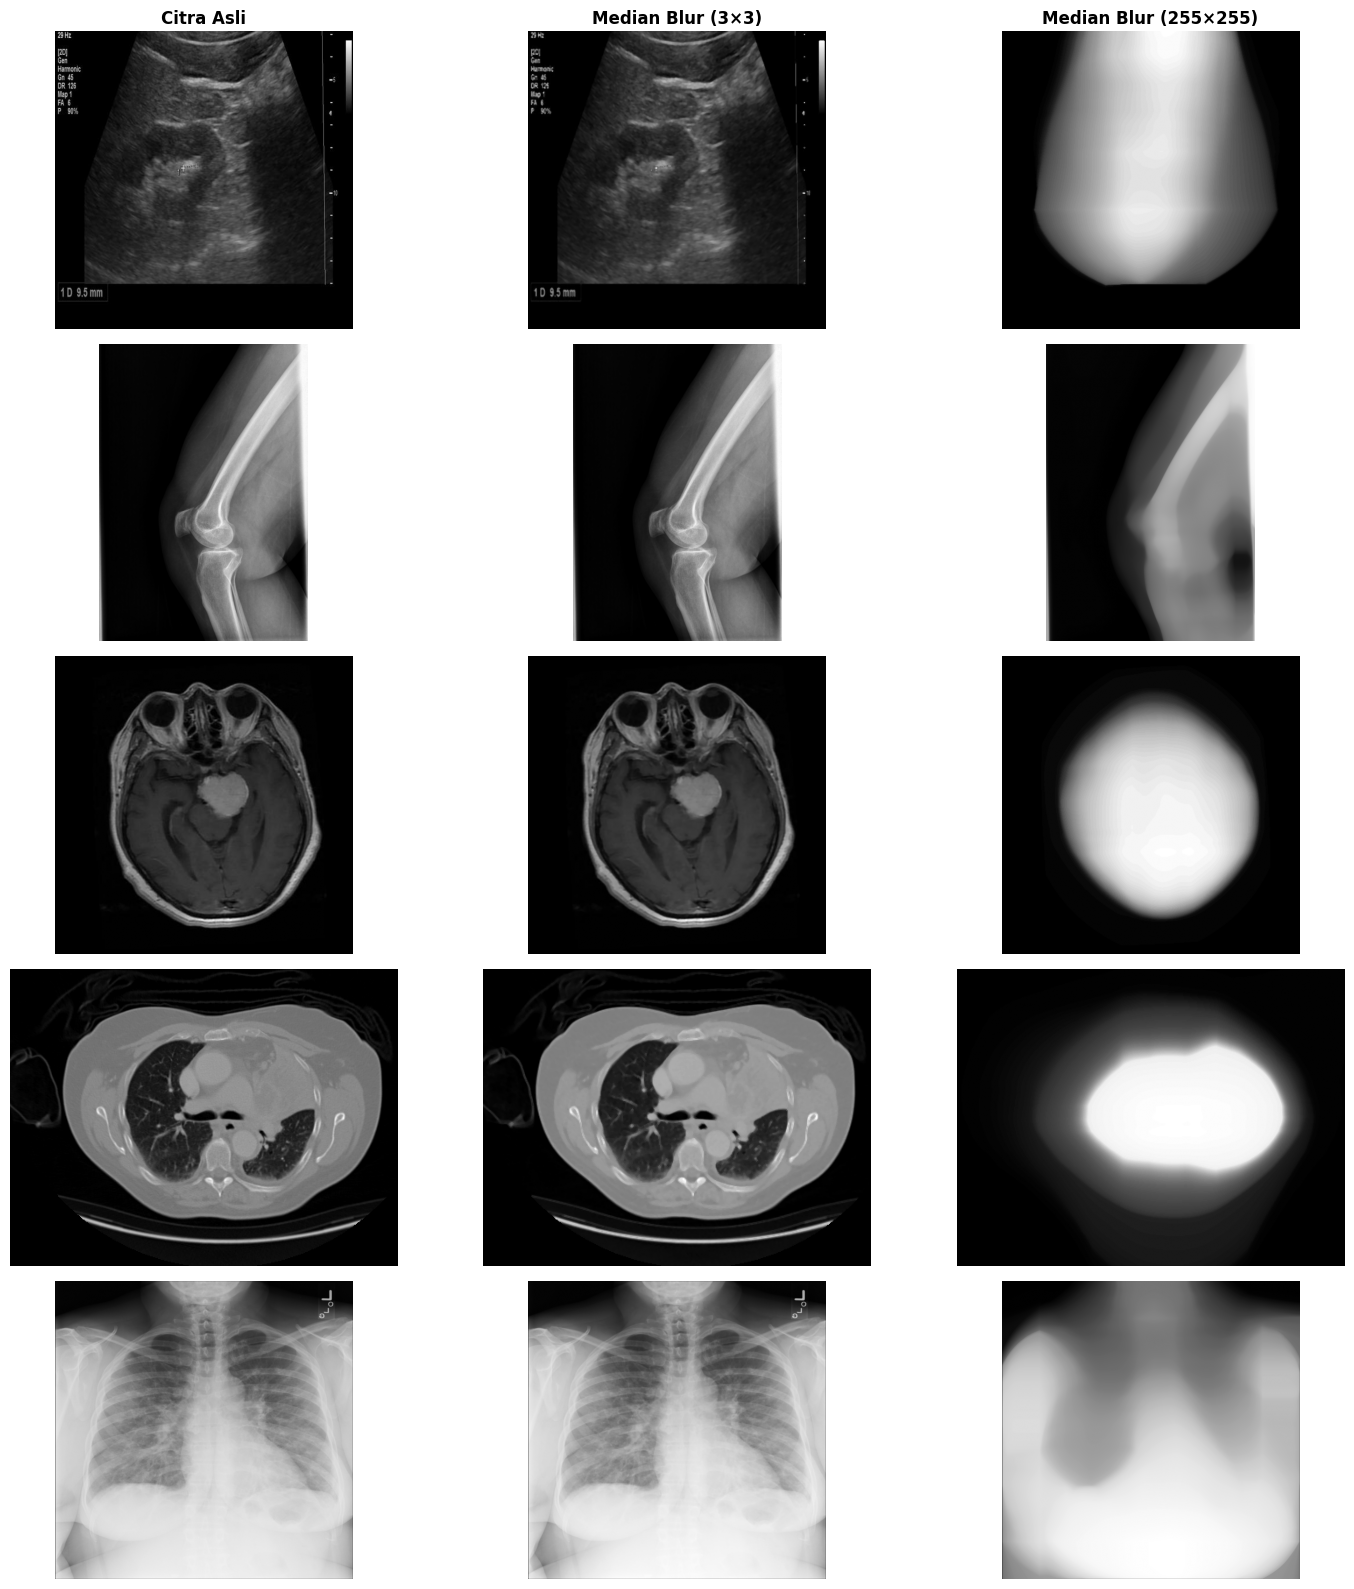

In [5]:
median_min = []
median_max = []

for img in gambar:
    median_min.append(cv2.medianBlur(img, 3))
    median_max.append(cv2.medianBlur(img, 255))
fig, axes = plt.subplots(5, 3, figsize=(15, 16))

nama_proses = [
    'Citra Asli',
    'Median Blur (3×3)',
    'Median Blur (255×255)'
]

for row in range(len(gambar)):
    hasil = [
        gambar[row],
        median_min[row],
        median_max[row]
    ]
    for col in range(3):
        axes[row, col].imshow(hasil[col], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(
                nama_proses[col],
                fontsize=12,
                fontweight='bold'
            )
    axes[row, 0].set_ylabel(
        judul[row],
        fontsize=12,
        fontweight='bold',
        rotation=90,
        labelpad=15
    )

plt.tight_layout()
plt.show()

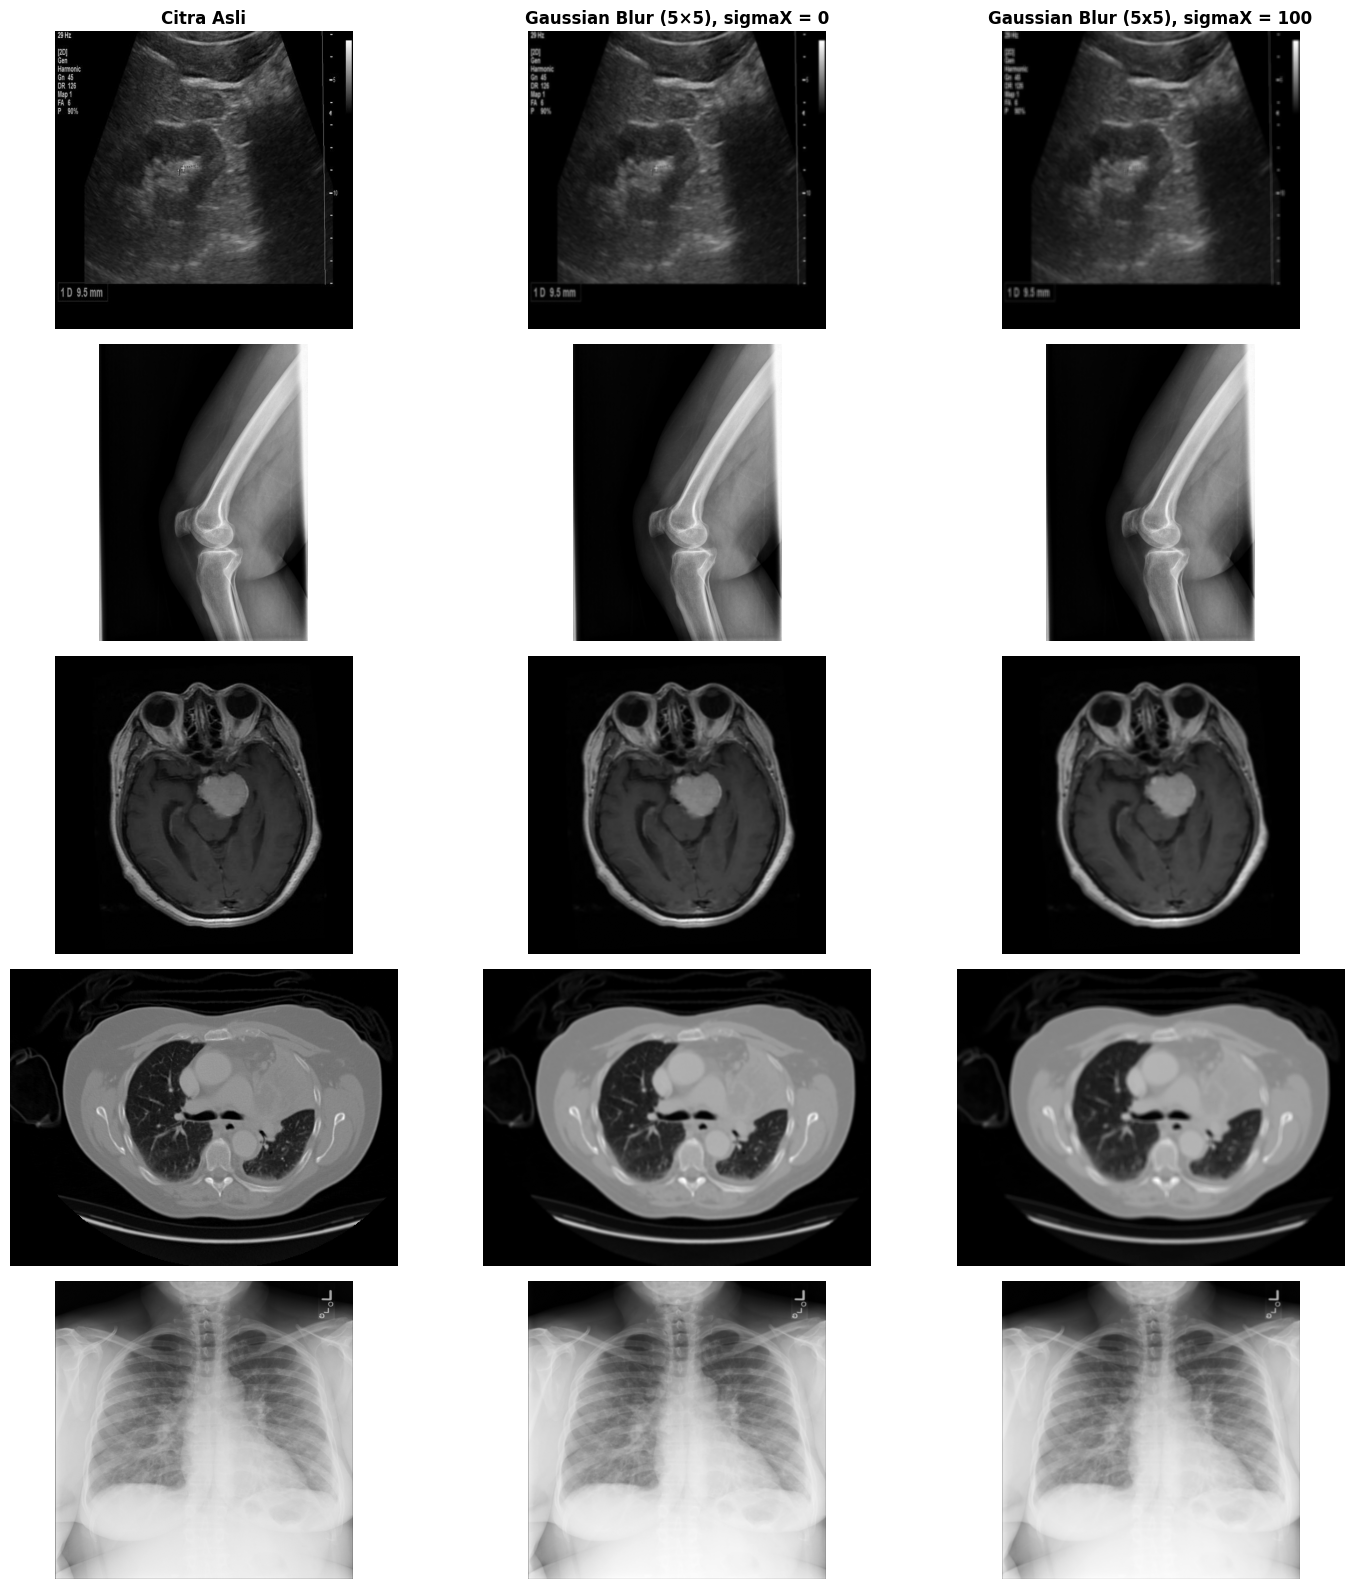

In [6]:
gauss_min = []
gauss_max = []

for img in gambar:
    gauss_min.append(cv2.GaussianBlur(img, (5,5) ,0))
    gauss_max.append(cv2.GaussianBlur(img, (5, 5), 100))
fig, axes = plt.subplots(5, 3, figsize=(15, 16))

nama_proses = [
    'Citra Asli',
    'Gaussian Blur (5×5), sigmaX = 0',
    'Gaussian Blur (5x5), sigmaX = 100'
]

for row in range(len(gambar)):
    hasil = [
        gambar[row],
        gauss_min[row],
        gauss_max[row]
    ]
    for col in range(3):
        axes[row, col].imshow(hasil[col], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(
                nama_proses[col],
                fontsize=12,
                fontweight='bold'
            )
    axes[row, 0].set_ylabel(
        judul[row],
        fontsize=12,
        fontweight='bold',
        rotation=90,
        labelpad=15
    )

plt.tight_layout()
plt.show()

In [7]:
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

def hitung_kualitas(citra_asli, citra_hasil):
    """PSNR (dB) dan SSIM antara citra hasil filtering dan citra asli."""
    nilai_psnr = psnr_metric(citra_asli, citra_hasil, data_range=255)
    nilai_ssim = ssim_metric(citra_asli, citra_hasil, data_range=255)
    return nilai_psnr, nilai_ssim

data_statistik = []

for i in range(len(gambar)):
    tinggi, lebar = gambar[i].shape
    sisi_terpendek = min(tinggi, lebar)

    psnr_g0, ssim_g0     = hitung_kualitas(gambar[i], gauss_min[i])
    psnr_g100, ssim_g100 = hitung_kualitas(gambar[i], gauss_max[i])
    psnr_m3, ssim_m3     = hitung_kualitas(gambar[i], median_min[i])
    psnr_m255, ssim_m255 = hitung_kualitas(gambar[i], median_max[i])

    data_statistik.append({
        'Citra': judul[i],

        # --- info ukuran citra & kernel relatif, untuk dibahas di bagian Hasil ---
        'Resolusi (HxW)': f'{tinggi}x{lebar}',
        'Kernel 3px (% sisi terpendek)': round(3 / sisi_terpendek * 100, 3),
        'Kernel 255px (% sisi terpendek)': round(255 / sisi_terpendek * 100, 2),

        ('Normal', 'Mean'): gambar[i].mean(),
        ('Normal', 'Std'): gambar[i].std(),

        ('Gaussian sigmaX 0', 'Mean'): gauss_min[i].mean(),
        ('Gaussian sigmaX 0', 'Std'): gauss_min[i].std(),
        ('Gaussian sigmaX 0', 'PSNR'): psnr_g0,
        ('Gaussian sigmaX 0', 'SSIM'): ssim_g0,

        ('Gaussian sigmaX 100', 'Mean'): gauss_max[i].mean(),
        ('Gaussian sigmaX 100', 'Std'): gauss_max[i].std(),
        ('Gaussian sigmaX 100', 'PSNR'): psnr_g100,
        ('Gaussian sigmaX 100', 'SSIM'): ssim_g100,

        ('Median kernel 3', 'Mean'): median_min[i].mean(),
        ('Median kernel 3', 'Std'): median_min[i].std(),
        ('Median kernel 3', 'PSNR'): psnr_m3,
        ('Median kernel 3', 'SSIM'): ssim_m3,

        ('Median kernel 255', 'Mean'): median_max[i].mean(),
        ('Median kernel 255', 'Std'): median_max[i].std(),
        ('Median kernel 255', 'PSNR'): psnr_m255,
        ('Median kernel 255', 'SSIM'): ssim_m255,
    })

df_statistik = pd.DataFrame(data_statistik).set_index('Citra')
df_statistik

,Resolusi (HxW),Kernel 3px (% sisi terpendek),Kernel 255px (% sisi terpendek),"(Normal, Mean)","(Normal, Std)","(Gaussian sigmaX 0, Mean)","(Gaussian sigmaX 0, Std)","(Gaussian sigmaX 0, PSNR)","(Gaussian sigmaX 0, SSIM)","(Gaussian sigmaX 100, Mean)",...,"(Gaussian sigmaX 100, PSNR)","(Gaussian sigmaX 100, SSIM)","(Median kernel 3, Mean)","(Median kernel 3, Std)","(Median kernel 3, PSNR)","(Median kernel 3, SSIM)","(Median kernel 255, Mean)","(Median kernel 255, Std)","(Median kernel 255, PSNR)","(Median kernel 255, SSIM)"
Citra,,,,,,,,,,,,,,,,,,,,,
Batu Ginjal,512x512,0.586,49.80,31.588848,34.089013,31.593124,32.376577,30.655239,0.947757,31.598930,...,27.960171,0.886553,31.207893,33.009118,30.541333,0.962525,21.360046,20.823152,19.539697,0.607762
Osteoarthritis,2343x1644,0.182,15.51,66.372123,69.354624,66.371068,69.269998,39.280363,0.921681,66.369064,...,37.887245,0.892175,66.355401,69.277540,38.845929,0.914550,66.011333,66.633212,26.016021,0.820096
Tumor Otak,512x512,0.586,49.80,27.581001,35.863234,27.582134,35.298461,40.583748,0.986017,27.580997,...,35.965019,0.961923,27.560066,35.698933,45.815985,0.993985,15.342068,20.157708,17.762450,0.705500
Chest X-ray,340x443,0.882,75.00,58.325813,60.483602,58.313756,59.595285,34.803807,0.949084,58.312077,...,30.515475,0.882497,58.115748,60.292461,40.579204,0.973915,29.762409,41.577023,12.529651,0.433902
Adenocarcinoma,1024x1024,0.293,24.90,161.096853,62.801015,161.213571,62.512251,34.183175,0.981920,161.242316,...,32.075032,0.968123,161.074261,62.771226,47.657892,0.988751,156.099635,59.928744,20.648815,0.858139


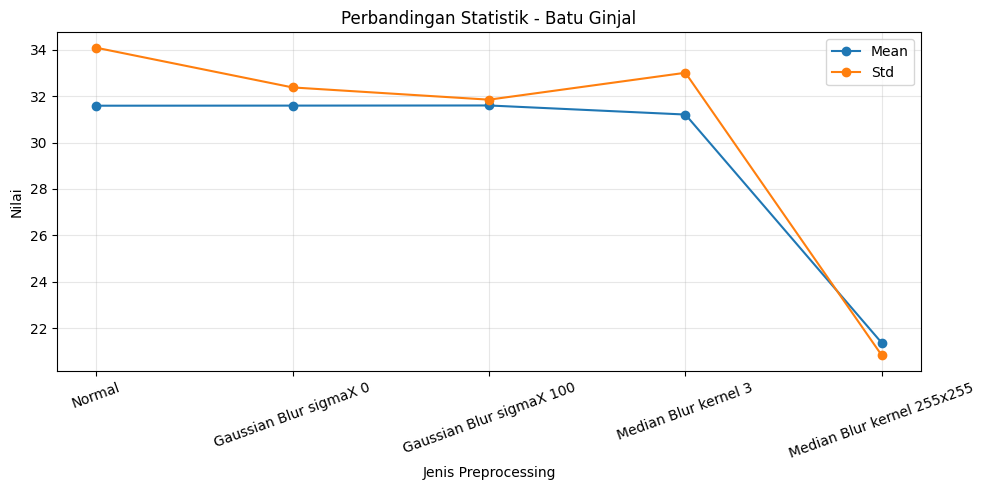

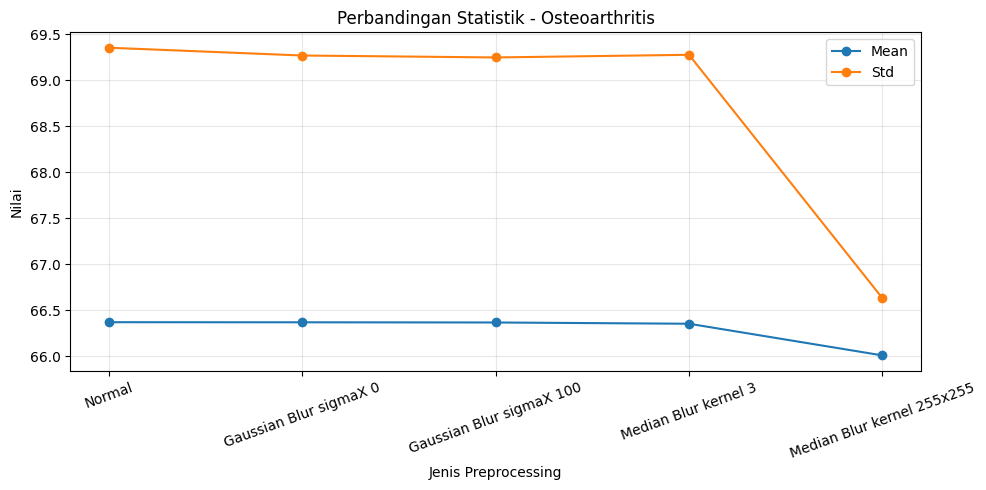

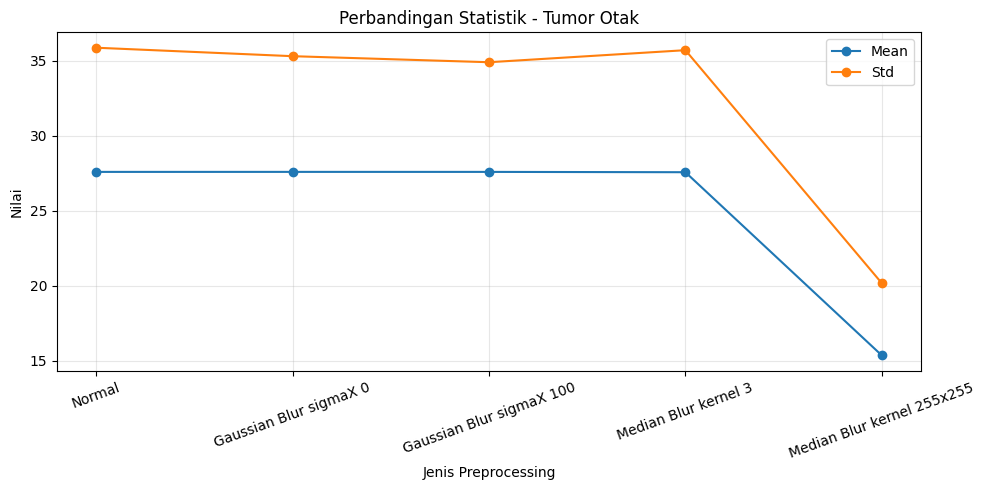

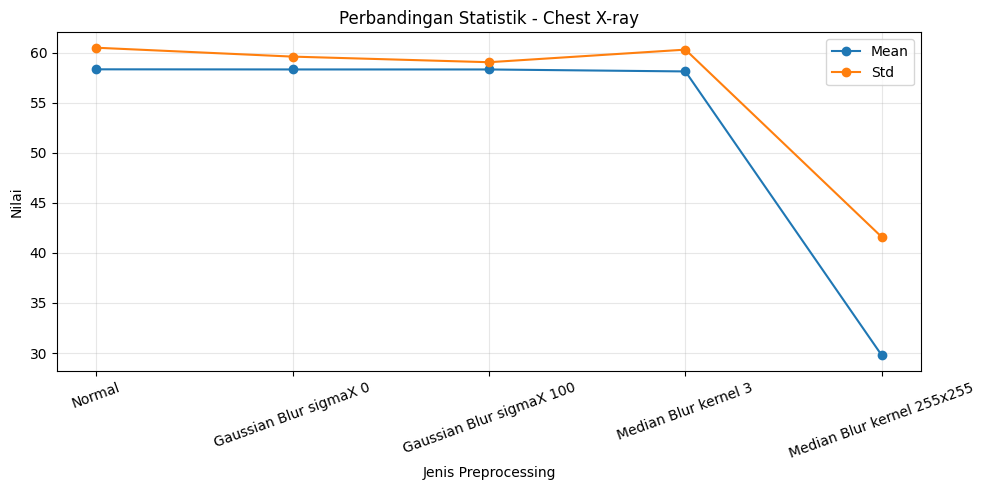

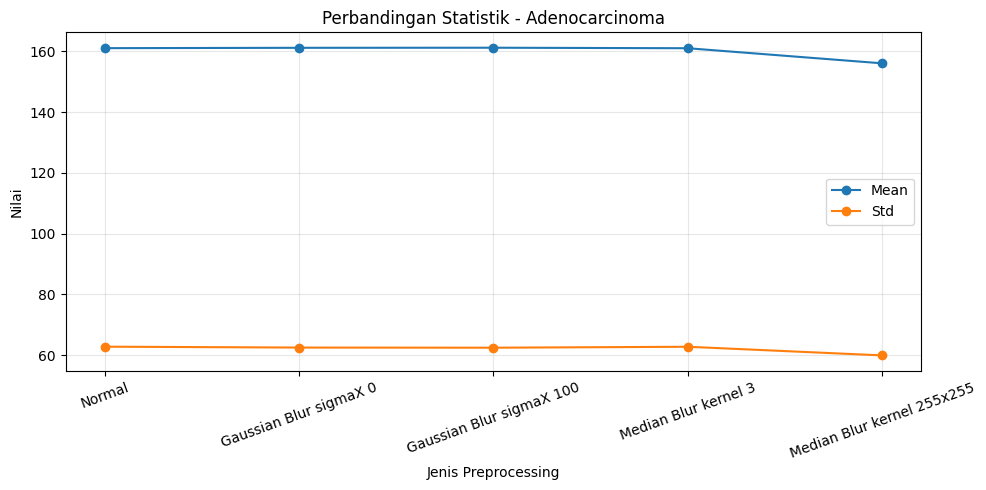

In [8]:
import matplotlib.pyplot as plt

proses = [
    'Normal',
    'Gaussian Blur sigmaX 0',
    'Gaussian Blur sigmaX 100',
    'Median Blur kernel 3',
    'Median Blur kernel 255x255'
]

for i in range(len(gambar)):
    mean = [
        gambar[i].mean(),
        gauss_min[i].mean(),
        gauss_max[i].mean(),
        median_min[i].mean(),
        median_max[i].mean()
    ]

    std = [
        gambar[i].std(),
        gauss_min[i].std(),
        gauss_max[i].std(),
        median_min[i].std(),
        median_max[i].std()
    ]

    # Buat grafik
    plt.figure(figsize=(10, 5))

    plt.plot(proses, mean, marker='o', label='Mean')
    plt.plot(proses, std, marker='o', label='Std')

    plt.title(f'Perbandingan Statistik - {judul[i]}')
    plt.xlabel('Jenis Preprocessing')
    plt.ylabel('Nilai')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

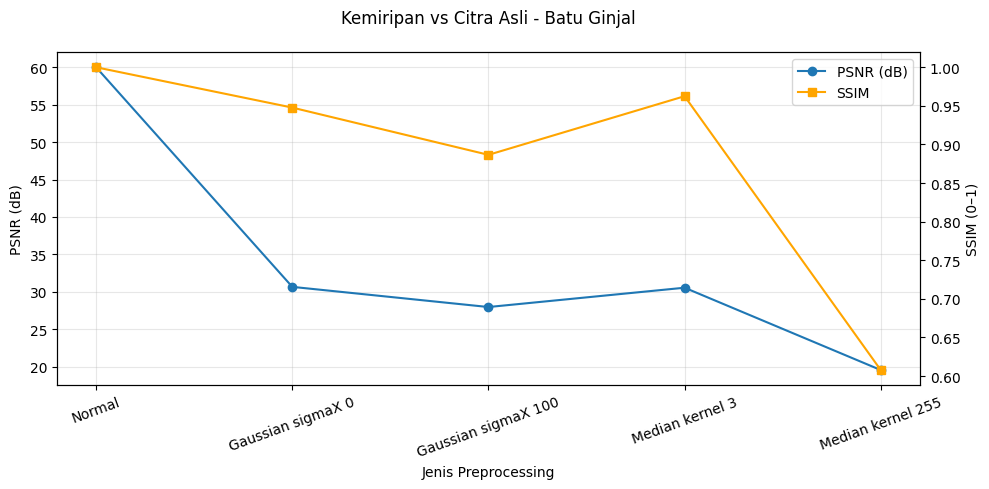

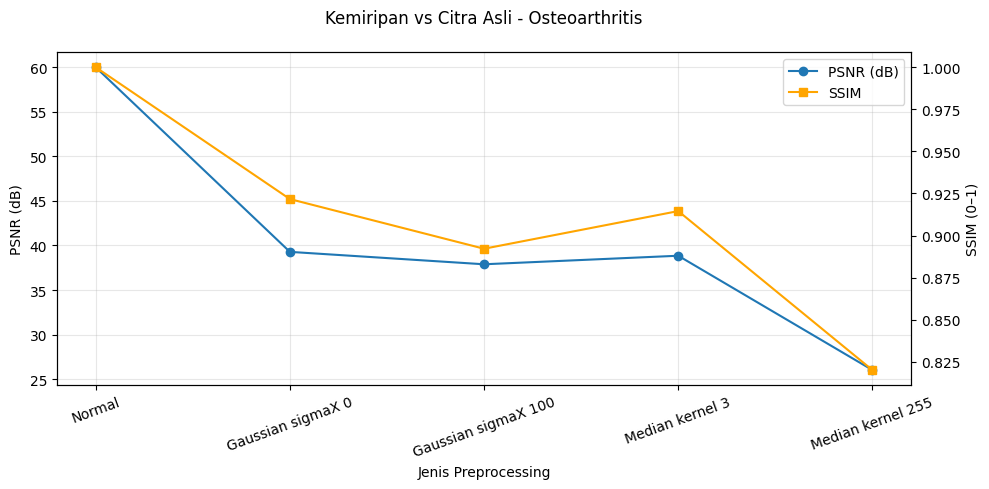

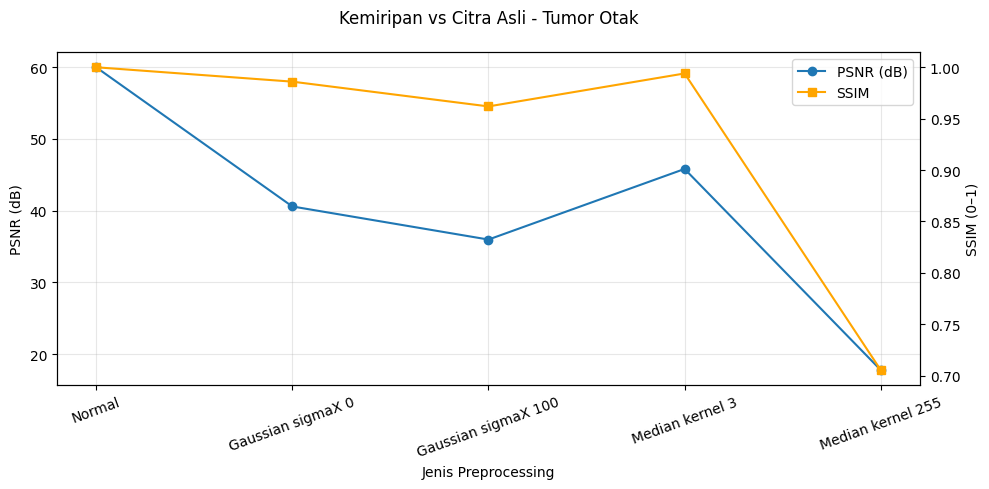

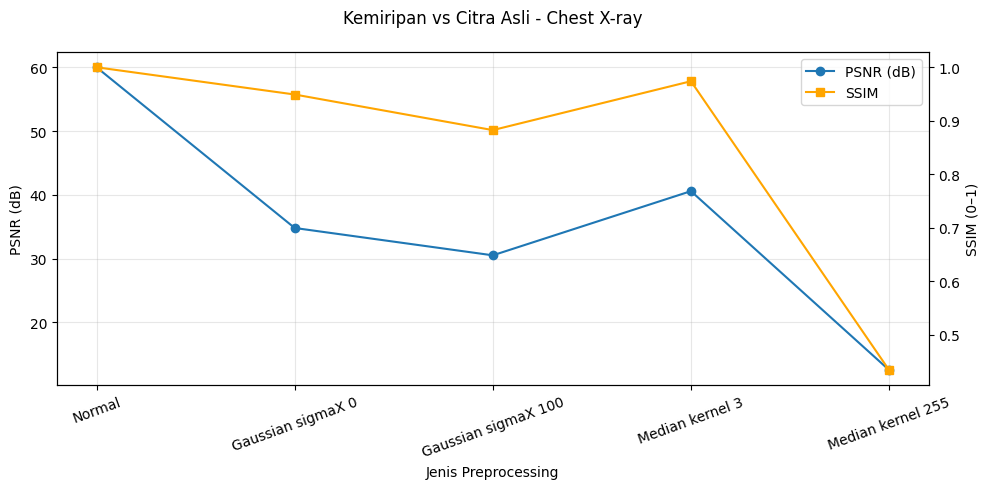

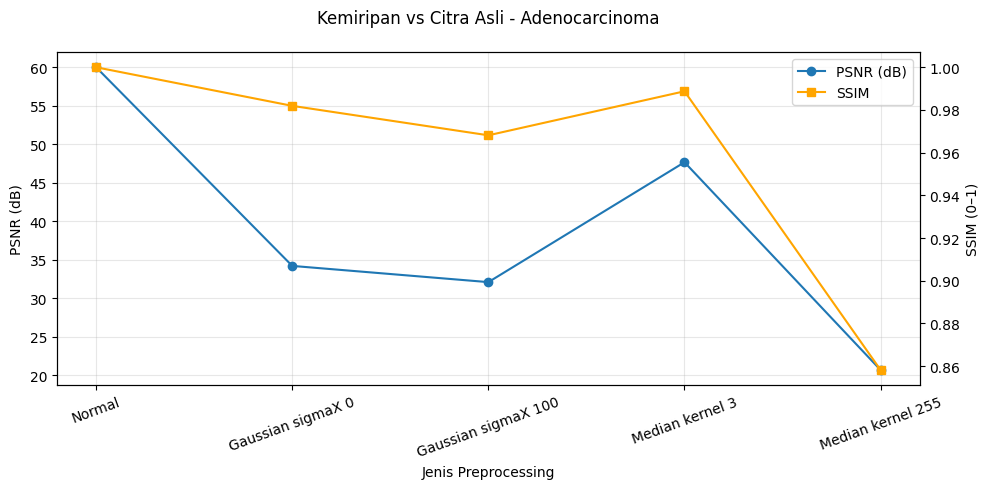

In [9]:
import matplotlib.pyplot as plt

proses = [
    'Normal',
    'Gaussian sigmaX 0',
    'Gaussian sigmaX 100',
    'Median kernel 3',
    'Median kernel 255'
]

for i in range(len(gambar)):
    asli = gambar[i]
    tinggi, lebar = asli.shape
    sisi_terpendek = min(tinggi, lebar)

    hasil_semua = [
        asli,
        gauss_min[i],
        gauss_max[i],
        median_min[i],
        median_max[i]
    ]

    # =========================
    # PSNR
    # =========================
    psnr_vals = []

    for idx, im in enumerate(hasil_semua):
        psnr_vals.append(
            float('inf')
            if idx == 0
            else psnr_metric(asli, im, data_range=255)
        )

    psnr_plot = [
        60 if v == float('inf') else v
        for v in psnr_vals
    ]

    # =========================
    # SSIM
    # =========================
    ssim_vals = [
        ssim_metric(asli, im, data_range=255)
        for im in hasil_semua
    ]

    # =========================
    # Grafik PSNR & SSIM
    # =========================
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # PSNR
    l1, = ax1.plot(
        proses,
        psnr_plot,
        marker='o',
        label='PSNR (dB)'
    )

    ax1.set_xlabel('Jenis Preprocessing')
    ax1.set_ylabel('PSNR (dB)')
    ax1.tick_params(axis='x', rotation=20)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()

    l2, = ax2.plot(
        proses,
        ssim_vals,
        marker='s',
        color='orange',
        label='SSIM'
    )

    ax2.set_ylabel('SSIM (0–1)')

    # =========================
    # Informasi ukuran kernel
    # =========================
    kernel3_pct = round(
        3 / sisi_terpendek * 100,
        2
    )

    kernel255_pct = round(
        255 / sisi_terpendek * 100,
        2
    )

    ax1.set_title(
        f'Kemiripan vs Citra Asli - {judul[i]}\n'
        # f'Kernel 3px = {kernel3_pct}% & '
        # f'kernel 255px = {kernel255_pct}% '
        # f'dari sisi terpendek citra'
    )

    # Gabungkan legend PSNR + SSIM
    ax1.legend(
        handles=[l1, l2],
        loc='upper right'
    )

    plt.tight_layout()
    plt.show()